# Chapter 6 — Fine-tuning for classification

Chapter 5 produced a reusable GPT architecture and loaded pretrained OpenAI weights. This chapter adapts those representations to a
binary supervised task: classifying SMS messages as legitimate (`ham`) or unwanted (`spam`).

For a modern instruction-tuned LLM, prompting should normally be evaluated before task-specific fine-tuning. This GPT-2-sized model is
not instruction-tuned, however, and the chapter's main purpose is pedagogical: learning dataset preparation, classification heads,
parameter freezing, supervised loss, and evaluation. A production spam system should still be compared with simpler baselines such as
TF–IDF plus logistic regression.

## 6.1 Downloading the SMS Spam Collection

The UCI dataset contains 5,572 labeled SMS messages in a small ZIP archive. Keep acquisition idempotent: if the final TSV already exists,
skip network and extraction work so rerunning the notebook does not overwrite local data.

In [1]:
import os
import urllib.request
import zipfile
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(
    url: str,
    zip_path: str | Path,
    extracted_path: str | Path,
    data_file_path: Path,
) -> None:
    """Download and extract the UCI SMS Spam Collection when absent.

    Args:
        url: URL of the source ZIP archive.
        zip_path: Local path used for the downloaded archive.
        extracted_path: Directory that receives extracted archive members.
        data_file_path: Final path of the renamed tab-separated dataset.

    Returns:
        None.

    Raises:
        urllib.error.URLError: If the dataset download fails.
        zipfile.BadZipFile: If the downloaded archive is invalid.
        OSError: If writing, extracting, or renaming a file fails.
    """
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # The archive is small enough to download into memory before writing.
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # The URL is a trusted UCI source; extract its members into one directory.
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Give the extensionless source file a .tsv suffix that describes its format.
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


## 6.2 Loading messages into a dataframe

The source is tab-separated and has no header. Assign `Label` to the external `ham`/`spam` category and `Text` to the raw message. Each
row is one supervised example; the two columns are its target and input.

In [2]:
import pandas as pd

# df: (num_messages=5_572, num_columns=2)
# The source file has no header, so assign descriptive column names.
df = pd.read_csv(
    data_file_path,
    sep="	",
    header=None,
    names=["Label", "Text"],
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


### Inspecting class balance

The original dataset contains many more ham messages than spam messages. A classifier that favors ham could therefore obtain deceptively
high raw accuracy without learning useful spam detection.

In [3]:
# Count examples before balancing to expose the original class imbalance.
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


## 6.3 Creating a balanced pedagogical dataset

Keep all 747 spam examples and randomly select 747 ham examples. The fixed seed makes the selected subset reproducible.

Downsampling makes accuracy easier to interpret and reduces training cost, but discards most legitimate messages and changes class
prevalence. It is a teaching simplification rather than a universally preferred production strategy.

In [4]:
def create_balanced_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Downsample ham messages to match the number of spam messages.

    Args:
        df: SMS examples with `Label` and `Text` columns.

    Returns:
        Dataframe containing every spam example and an equally sized,
        reproducibly sampled ham subset.
    """
    # num_spam is the minority-class row count: 747 for this dataset.
    num_spam = df[df["Label"] == "spam"].shape[0]
    # Keep a reproducible subset instead of allowing the majority class to dominate.
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam,
        random_state=123,
    )
    # balanced_df: (2 * num_spam, num_columns=2)
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    return balanced_df


balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


### Encoding class labels

Cross-entropy expects integer class targets rather than strings. Map legitimate messages to `0` and spam messages to `1`; these meanings
must remain consistent through datasets, training, evaluation, and inference.

In [5]:
# Convert external string labels into integer targets for cross-entropy.
# ham -> 0 and spam -> 1; balanced_df remains (num_messages=1_494, 2).
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

## 6.4 Creating training, validation, and test splits

Shuffle once with a fixed seed, then allocate 70% for parameter updates, 10% for model-selection feedback, and the remaining 20% for a
final held-out estimate. The test set must not guide training decisions.

Integer boundaries can cause a one-row rounding difference from the exact percentages. All rows still belong to exactly one split.

In [6]:
def random_split(
    df: pd.DataFrame,
    train_frac: float,
    validation_frac: float,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Shuffle and partition examples into training, validation, and test sets.

    Args:
        df: Labeled examples to partition.
        train_frac: Fraction assigned to the training set.
        validation_frac: Fraction assigned to the validation set. The remaining
            fraction becomes the test set.

    Returns:
        Training, validation, and test dataframes in that order.
    """
    # Shuffle reproducibly so the concatenated classes are mixed before slicing.
    shuffled_df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(shuffled_df) * train_frac)
    validation_end = train_end + int(len(shuffled_df) * validation_frac)

    # With 70%/10%, the unspecificed final 20% becomes the held-out test set.
    train_df = shuffled_df[:train_end]
    validation_df = shuffled_df[train_end:validation_end]
    test_df = shuffled_df[validation_end:]

    return train_df, validation_df, test_df


train_df, validation_df, test_df = random_split(
    balanced_df,
    train_frac=0.7,
    validation_frac=0.1,
)
train_df.shape, validation_df.shape, test_df.shape

((1045, 2), (149, 2), (300, 2))

### Saving reproducible split files

Write each dataframe to a separate CSV. Omitting the pandas index prevents an unrelated numeric column from becoming accidental model
input when the files are loaded later.

In [7]:
# Persist each split without a redundant dataframe-index column.
train_df.to_csv("train.csv", index=False)
validation_df.to_csv("validation.csv", index=False)
test_df.to_csv("test.csv", index=False)

## 6.5 Reusing the GPT-2 tokenizer

Classification inputs must use the same token-to-ID mapping as pretraining. GPT-2's `<|endoftext|>` marker has a dedicated vocabulary
ID when explicitly permitted through `allowed_special`.

The next dataset stage can use this known token as a separator or padding value without expanding `vocab_size`. Encoding returns a Python
list containing one token ID; tensors and batches will be constructed later.

In [8]:
import tiktoken

# Reuse the tokenizer whose vocabulary matches the pretrained GPT-2 weights.
tokenizer = tiktoken.get_encoding("gpt2")
# One special end-of-text marker encodes as (num_tokens=1,).
endoftext_id = tokenizer.encode(
    "<|endoftext|>",
    allowed_special={"<|endoftext|>"},
)
print(endoftext_id)

[50256]


## 6.6 Building a fixed-length classification dataset

PyTorch batches require examples with compatible shapes, but SMS messages contain different token counts. `SpamDataset` therefore:

1. loads one saved split;
2. tokenizes every message with GPT-2;
3. chooses or accepts a shared `max_length`;
4. truncates messages that exceed that length;
5. pads shorter messages with GPT-2's end-of-text token ID; and
6. returns each token-ID tensor with its integer class label.

```text
one input       (num_tokens=max_length,)
one label       ()
complete batch  (batch_size, num_tokens=max_length)
batch labels    (batch_size,)
```

When training, validation, and test datasets are created, they should receive the same explicit `max_length`—normally derived from the
training set and capped at the model's `context_length`. Deriving it independently for each split would produce incompatible shapes and
allow validation or test data to influence preprocessing.

In [9]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset[tuple[torch.Tensor, torch.Tensor]]):
    """Tokenize, truncate, and pad labeled SMS messages from one CSV split."""

    def __init__(
        self,
        csv_file: str | Path,
        tokenizer: tiktoken.Encoding,
        max_length: int | None = None,
        pad_token_id: int = 50256,
    ) -> None:
        """Load one split and prepare fixed-length token-ID sequences.

        Args:
            csv_file: CSV containing `Text` and integer `Label` columns.
            tokenizer: GPT-2 tokenizer used to encode each message.
            max_length: Token IDs retained per message. When `None`, use the
                longest encoded message in this split.
            pad_token_id: Token ID appended to shorter messages. GPT-2 uses
                `50256` for its end-of-text token.
        """
        # data: (num_messages, num_columns=2)
        self.data = pd.read_csv(csv_file)

        # Each inner list initially has its message's natural num_tokens.
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

        if max_length is None:
            # Derive one shared length from the longest message in this split.
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncation prevents inputs from exceeding the selected capacity.
            self.encoded_texts = [
                encoded_text[: self.max_length] for encoded_text in self.encoded_texts
            ]

        # Every inner list now has num_tokens=max_length, enabling batching.
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(
        self,
        index: int,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Return one fixed-length input and its scalar class label.

        Args:
            index: Zero-based row position in this dataset split.

        Returns:
            Input token IDs shaped `(num_tokens=max_length,)` and a scalar
            class-label tensor shaped `()`.

        Raises:
            IndexError: If `index` is outside the dataset.
        """
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        # encoded_tensor: (num_tokens=max_length,); label_tensor: ()
        encoded_tensor = torch.tensor(encoded, dtype=torch.long)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return encoded_tensor, label_tensor

    def __len__(self) -> int:
        """Return the number of labeled messages in this split.

        Returns:
            Number of rows loaded from the CSV file.
        """
        return len(self.data)

    def _longest_encoded_length(self) -> int:
        """Find the largest natural token count in this split.

        Returns:
            Maximum encoded-message length, or `0` for an empty split.
        """
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

## 6.7 Instantiating consistent dataset splits

Create the training dataset first with `max_length=None`. Only training data may determine preprocessing choices; validation and test
sets remain unseen sources of evaluation evidence.

In [10]:
# Derive one preprocessing length from training data only.
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer,
)

### Inspecting the training-derived length

The longest training message contains 120 GPT-2 token IDs. This is well below GPT-2 small's configured `context_length=1_024`, so every
training message fits without exceeding model capacity.

In [11]:
# The longest training message contains this many GPT-2 token IDs.
print("Training max_length:", train_dataset.max_length)

Training max_length: 120


### Applying one length to held-out splits

Pass the training dataset's `max_length` into validation and test datasets. This produces compatible tensors and prevents held-out
messages from determining input shape. Any held-out message longer than 120 tokens is deliberately truncated.

In [12]:
# Reuse the training-derived length so every split has compatible shapes.
# Longer validation or test messages are truncated instead of influencing setup.
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer,
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer,
)

## 6.8 Building classification data loaders

A data loader stacks dataset items into batches:

```text
input_batch   (batch_size, num_tokens)
target_batch  (batch_size,)
```

Shuffle training examples so successive optimizer steps see different class combinations. Keep validation and test order stable because
evaluation does not update parameters.

`drop_last=True` discards the training remainder so every optimizer step has eight examples. It is convenient rather than architecturally
required here. Evaluation uses `drop_last=False` because accuracy must include every held-out example.

In [13]:
from torch.utils.data import DataLoader

# Zero worker subprocesses are reliable in an interactive Windows notebook.
num_workers = 0
batch_size = 8
# Fix the training loader's shuffled row order for reproducibility.
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    # Keep every optimizer step at the configured batch_size.
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    # Evaluation must include the final incomplete batch.
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=False,
)

### Inspecting one complete batch

Read only the first training batch to confirm the dataset–loader contract. The leading dimension contains eight independent messages;
the second contains 120 padded token positions. Labels provide one scalar target per message.

In [14]:
# Read one batch without traversing the complete training loader.
input_batch, target_batch = next(iter(train_loader))
# input_batch: (batch_size=8, num_tokens=120)
# target_batch: (batch_size=8,)
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions:", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions: torch.Size([8])


### Counting optimizer and evaluation batches

`len(data_loader)` reports how many batches an iteration yields. The training count excludes its incomplete remainder, whereas validation
and test counts include their smaller final batches.

In [15]:
# len(loader) counts batches rather than individual examples.
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


## 6.9 Loading pretrained GPT-2 weights

Classification fine-tuning should begin with general language representations rather than random parameters. Select a GPT-2 variant,
construct the exact matching `GPTConfig`, download its OpenAI checkpoint, and copy every converted array into the local architecture.

The checkpoint retains its full `context_length=1_024`, although SMS preprocessing uses only 120 token positions. Model capacity and the
current input's `num_tokens` are different concepts.

### Selecting checkpoint dimensions

Each OpenAI GPT-2 size changes embedding width, attention-head count, and Transformer-layer count. Store those values under the canonical
`GPTConfig` identifiers so changing `CHOOSE_MODEL` updates the complete local architecture rather than silently retaining small-model
dimensions.

In [16]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

# Model-specific dimensions use the canonical GPTConfig field names.
model_configs = {
    "gpt2-small (124M)": {
        "emb_dim": 768,
        "num_layers": 12,
        "num_heads": 12,
    },
    "gpt2-medium (355M)": {
        "emb_dim": 1024,
        "num_layers": 24,
        "num_heads": 16,
    },
    "gpt2-large (774M)": {
        "emb_dim": 1280,
        "num_layers": 36,
        "num_heads": 20,
    },
    "gpt2-xl (1558M)": {
        "emb_dim": 1600,
        "num_layers": 48,
        "num_heads": 25,
    },
}

### Reconstructing and loading the selected model

The download helper supplies exact vocabulary and context metadata plus converted parameter arrays. Combine that metadata with the
selected model dimensions, validate it through `GPTConfig`, instantiate `GPTModel`, and copy the checkpoint arrays.

At this point the model remains on CPU. A later training section can move it and each batch to the same CUDA device.

In [17]:
from gpt_download import download_and_load_gpt2

from build_llms_from_scratch_companion.model import GPTConfig, GPTModel
from build_llms_from_scratch_companion.training import load_weights_into_gpt

# Extract the helper's checkpoint-size identifier, such as "124M".
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2",
)
# Combine exact checkpoint metadata with the selected variant dimensions.
cfg = GPTConfig(
    vocab_size=settings["n_vocab"],
    context_length=settings["n_ctx"],
    dropout_rate=0.0,
    qkv_bias=True,
    **model_configs[CHOOSE_MODEL],
)
model = GPTModel(cfg)
load_weights_into_gpt(model, params)
# Disable dropout for deterministic baseline generation.
model.eval()
print("Loaded pretrained model:", CHOOSE_MODEL)

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe
Loaded pretrained model: gpt2-small (124M)


## 6.10 Verifying ordinary pretrained generation

Before changing the architecture, generate a short continuation as a sanity check. Coherent output confirms that configuration, weight
mapping, tokenization, and the language-model output head agree.

In [18]:
from build_llms_from_scratch_companion.generation import generate_text_simple
from build_llms_from_scratch_companion.training import (
    text_to_token_ids,
    token_ids_to_text,
)

# Tokenization creates CPU IDs; place them beside the model parameters.
model_device = next(model.parameters()).device
# input_ids: (batch_size=1, num_tokens=3)
input_ids = text_to_token_ids(INPUT_PROMPT, tokenizer).to(model_device)
# token_ids: (batch_size=1, num_tokens=3 + max_new_tokens=15)
token_ids = generate_text_simple(
    model=model,
    idx=input_ids,
    max_new_tokens=15,
    context_size=cfg.context_length,
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves forward, but it's not enough.

"I'm not going


## 6.11 Testing the base model as a prompted classifier

Ask base GPT-2 for a yes/no spam decision before fine-tuning. The model instead continues patterns from the prompt because it was trained
for next-token prediction, not instruction following.

This is a qualitative baseline, not predictive-performance measurement. Accuracy becomes measurable only after a classification output,
labeled batches, and an evaluation function are connected.

In [19]:
spam_prompt = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
# prompt_ids: (batch_size=1, num_tokens)
prompt_ids = text_to_token_ids(spam_prompt, tokenizer).to(model_device)
token_ids = generate_text_simple(
    model=model,
    idx=prompt_ids,
    max_new_tokens=23,
    context_size=cfg.context_length,
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


## 6.12 Freezing pretrained parameters

Set every existing parameter's `requires_grad` flag to `False`. Forward passes still use all pretrained weights, but backpropagation does
not calculate or store their gradients. This reduces optimization cost and protects general language representations while the new
classifier starts from random values.

Freezing is applied before replacing the output head, so the subsequently created head remains trainable by default.

In [20]:
# Freeze embeddings, all Transformer blocks, normalization, and the old head.
for parameter in model.parameters():
    parameter.requires_grad = False

## 6.13 Replacing vocabulary prediction with class prediction

The pretrained output head maps each token representation from `emb_dim=768` to `vocab_size=50_257` next-token logits. Classification
instead needs two scores—one for ham and one for spam—so replace only that projection:

```text
before  (batch_size, num_tokens, vocab_size)
after   (batch_size, num_tokens, num_classes=2)
```

The new linear layer is randomly initialized and trainable. Moving it to the model's current device prevents a CPU/CUDA mismatch if the
base model was moved before this cell is rerun.

In [21]:
# Reproduce the random initialization of the new classification head.
torch.manual_seed(123)
num_classes = 2
model_device = next(model.parameters()).device
# Map each emb_dim representation to two class logits on the model's device.
model.out_head = torch.nn.Linear(
    in_features=cfg.emb_dim,
    out_features=num_classes,
).to(model_device)

## 6.14 Partially fine-tuning the representation

Training only the new head would be a **linear probe**: it can recombine existing GPT-2 features but cannot change those features for
spam detection. That is a valid, cheaper baseline and would be worth measuring first.

The book additionally unfreezes the final Transformer block and final layer normalization. This gives the model limited capacity to
adapt high-level representations while keeping the earlier eleven blocks fixed. It is a compromise between:

- **head-only training:** cheapest and least prone to overfitting;
- **partial fine-tuning:** more adaptable with moderate cost; and
- **full fine-tuning:** most adaptable but most expensive and easiest to overfit.

So your instinct is valid: retraining only the output head is possible. The final block and normalization are unfrozen because the
pretrained model was never taught that its representations should separate ham from spam.

In [22]:
# Adapt only the highest Transformer representations to classification.
for parameter in model.trf_blocks[-1].parameters():
    parameter.requires_grad = True
# Let the final normalization scale and shift adapt with those representations.
for parameter in model.final_norm.parameters():
    parameter.requires_grad = True

## 6.15 Inspecting the untrained classification output

Run one short message through the modified architecture before classification training. This checks tensor shapes, not predictive
performance. The classification head is still random, so its scores and implied class decision are not meaningful.

A causal GPT produces one representation per input position. The classifier therefore emits two class logits at every position, and the
next step selects the final position because it has attended to all preceding message tokens.

In [23]:
# Tokenization returns four CPU IDs; move the complete batch to the model.
input_ids = tokenizer.encode("Do you have time")
# inputs: (batch_size=1, num_tokens=4)
inputs = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(model_device)
print("Inputs:", inputs)
print("Input dimensions:", inputs.shape)

Inputs: tensor([[5211,  345,  423,  640]])
Input dimensions: torch.Size([1, 4])


In [24]:
# This is an inference-only shape check, so no gradients are required.
with torch.no_grad():
    # logits: (batch_size=1, num_tokens=4, num_classes=2)
    logits = model(inputs)
print("Class logits:", logits)
print("Class-logit dimensions:", logits.shape)

Class logits: tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Class-logit dimensions: torch.Size([1, 4, 2])


In [25]:
# The final position has processed every preceding token in the message.
# last_token_logits: (batch_size=1, num_classes=2)
last_token_logits = logits[:, -1, :]
print("Last-position class logits:", last_token_logits)

Last-position class logits: tensor([[-3.5983,  3.9902]])


### Why final-position classification is principled

Reusing GPT-2 for classification is less arbitrary than it may first appear. Causal attention gives each position access only to itself
and earlier positions. The final position is therefore the only representation with access to the complete input sequence:

```text
position 1      sees token 1
position 2      sees tokens 1–2
position i      sees tokens 1–i
final position  sees every input token
```

Replacing the vocabulary head with a two-class head preserves GPT's position-wise interface:

```text
hidden representations  (batch_size, num_tokens, emb_dim)
classification head     emb_dim → num_classes
class logits             (batch_size, num_tokens, num_classes)
selected logits          (batch_size, num_classes)
```

The outputs are **logits**, not probabilities; softmax can convert the selected logits into class probabilities. Earlier positions would
classify incomplete prefixes, so the loss uses only final-position logits. Fine-tuning then explicitly teaches that causally complete
representation to organize information useful for distinguishing ham from spam—it is not assumed to be a competent classifier before
training.

Earlier token computations are still essential. Their representations supply the keys and values attended to by the final position, and
gradients from the final-position loss flow through those attention paths into the trainable final block, normalization, and
classification head.

Applying the classification head at every position does calculate logits that are later ignored, but it keeps the existing `GPTModel`
forward interface unchanged and the linear projection is inexpensive relative to the Transformer. A specialized implementation could
project only the selected hidden representation.

One practical caveat remains: this notebook pads messages with repeated end-of-text IDs and selects the absolute final padded position.
That position still has access to the complete message, so the book's reasoning remains valid. More deliberate production alternatives
include selecting the final non-padding representation, appending a dedicated classification token, or using masked pooling.

## 6.16 Converting final-position logits into a class label

The classification head emits two unnormalized scores for the selected final position. A larger score means the current model favors that
class, but before supervised training this preference is random rather than evidence of useful spam detection.

In [26]:
# last_token_logits: (batch_size=1, num_classes=2)
print("Last-position class logits:", last_token_logits)

Last-position class logits: tensor([[-3.5983,  3.9902]])


### Producing class probabilities

Softmax normalizes the two logits independently for each example. The result has the same shape and sums to one across `num_classes`.
`argmax` then maps the largest probability to label `0` (ham) or `1` (spam).

In [27]:
# Convert the two class logits into probabilities that sum to 1.
# probas: (batch_size=1, num_classes=2)
probas = torch.softmax(last_token_logits, dim=-1)
# label: (batch_size=1,), one predicted class ID per example
label = torch.argmax(probas, dim=-1)
print("Class label:", label.item())

Class label: 1


### Predicting directly from logits

Softmax is unnecessary when only the predicted label is required. It changes magnitudes but preserves ordering, so `argmax(logits)` and
`argmax(softmax(logits))` select the same class while direct logit selection does less work.

In [28]:
# Softmax preserves score order, so argmax can operate on logits directly.
# label: (batch_size=1,)
label = torch.argmax(last_token_logits, dim=-1)
print("Class label:", label.item())

Class label: 1


## 6.17 Measuring classification accuracy

Accuracy is the number of correct predicted labels divided by the number of evaluated examples. For every batch, move inputs and targets
to the model's device, select final-position logits, and compare their `argmax` with the target labels.

Count correct examples globally instead of averaging per-batch percentages. This matters because validation and test loaders retain their
incomplete final batches. The optional `num_batches` bound supports quick checks, while full evaluation uses every available example.

In [29]:
def calc_accuracy_loader(
    data_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    model: GPTModel,
    device: torch.device,
    num_batches: int | None = None,
) -> float:
    """Calculate final-position classification accuracy over loader batches.

    Args:
        data_loader: Loader yielding input token IDs shaped
            `(batch_size, num_tokens)` and targets shaped `(batch_size,)`.
        model: GPT classifier producing logits shaped
            `(batch_size, num_tokens, num_classes)`.
        device: CPU or CUDA device shared by model and batches.
        num_batches: Maximum batches evaluated, or `None` for the full loader.

    Returns:
        Fraction of evaluated examples classified correctly.

    Raises:
        ZeroDivisionError: If no examples are evaluated.
    """
    # Evaluation mode disables dropout; remember the caller's prior mode.
    was_training = model.training
    model.eval()
    correct_predictions = 0
    num_examples = 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        # Never request more batches than the loader can provide.
        num_batches = min(num_batches, len(data_loader))

    for batch_index, (input_batch, target_batch) in enumerate(data_loader):
        if batch_index >= num_batches:
            break
        # input_batch: (batch_size, num_tokens)
        # target_batch: (batch_size,)
        input_batch = input_batch.to(device)
        target_batch = target_batch.to(device)

        with torch.no_grad():
            # Retain only final-position logits: (batch_size, num_classes)
            last_token_logits = model(input_batch)[:, -1, :]
        # predicted_labels: (batch_size,)
        predicted_labels = torch.argmax(last_token_logits, dim=-1)

        # Count examples rather than averaging batch accuracies so an incomplete
        # final batch receives the correct statistical weight.
        num_examples += predicted_labels.shape[0]
        correct_predictions += (predicted_labels == target_batch).sum().item()

    accuracy = correct_predictions / num_examples
    # Restore training or evaluation mode without performing an optimizer step.
    model.train(was_training)
    return accuracy

## 6.18 Establishing a pretraining accuracy baseline

Move the modified model to CUDA when available and evaluate ten batches from each split. Since the two classes are balanced and the
classification head is random, accuracy near 50% is expected.

These are fast sampled baselines rather than final metrics. Validation can guide development, while repeated test-set inspection should
be avoided once model-selection decisions begin.

In [30]:
# Use CUDA when available and keep the model and all batches together.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Reproduce the shuffled subset drawn from the training loader.
torch.manual_seed(123)
# Ten batches provide a fast baseline before any supervised optimization.
train_accuracy = calc_accuracy_loader(
    train_loader,
    model,
    device,
    num_batches=10,
)
val_accuracy = calc_accuracy_loader(
    val_loader,
    model,
    device,
    num_batches=10,
)
test_accuracy = calc_accuracy_loader(
    test_loader,
    model,
    device,
    num_batches=10,
)

print(f"Training accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation accuracy: {val_accuracy * 100:.2f}%")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


## 6.19 Calculating classification loss

Accuracy records only whether the selected class is correct. Cross-entropy also considers the complete score distribution, assigning a
larger penalty when the model is confidently wrong.

For one batch, select `(batch_size, num_classes)` final-position logits and compare them with `(batch_size,)` integer targets. PyTorch
cross-entropy performs log-softmax internally, so the function must receive raw logits rather than probabilities.

In [31]:
def calc_loss_batch(
    input_batch: torch.Tensor,
    target_batch: torch.Tensor,
    model: GPTModel,
    device: torch.device,
) -> torch.Tensor:
    """Calculate classification cross-entropy for one batch.

    Args:
        input_batch: Token IDs shaped `(batch_size, num_tokens)`.
        target_batch: Integer class labels shaped `(batch_size,)`.
        model: GPT classifier producing position-wise class logits.
        device: CPU or CUDA device shared by model and batches.

    Returns:
        Scalar mean cross-entropy tensor shaped `()`.
    """
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    # last_token_logits: (batch_size, num_classes=2)
    last_token_logits = model(input_batch)[:, -1, :]
    # Cross-entropy combines log-softmax with negative log-likelihood.
    loss = torch.nn.functional.cross_entropy(
        last_token_logits,
        target_batch,
    )
    return loss

### Averaging loss across batches

Accumulate scalar batch losses and divide by the requested batch count. `num_batches` supports quick estimates, while `None` traverses the
complete loader. The function intentionally does not disable gradients, allowing `calc_loss_batch` to be reused during training; callers
use `torch.no_grad()` for evaluation.

This book helper averages batch means equally. If a full loader includes a smaller final batch, exact example-weighted loss would instead
weight each batch loss by its number of examples.

In [32]:
def calc_loss_loader(
    data_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    model: GPTModel,
    device: torch.device,
    num_batches: int | None = None,
) -> float:
    """Average classification loss across loader batches.

    Args:
        data_loader: Loader yielding token IDs and integer class labels.
        model: GPT classifier evaluated on each batch.
        device: CPU or CUDA device shared by model and batches.
        num_batches: Maximum batches evaluated, or `None` for all batches.

    Returns:
        Mean of the selected batch losses, or `nan` when no batch is selected.
    """
    if len(data_loader) == 0:
        return float("nan")
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        # Bound quick evaluations to the available number of batches.
        num_batches = min(num_batches, len(data_loader))
    if num_batches <= 0:
        return float("nan")

    total_loss = 0.0
    for batch_index, (input_batch, target_batch) in enumerate(data_loader):
        if batch_index >= num_batches:
            break
        # loss is scalar; item() detaches its value as a Python float.
        loss = calc_loss_batch(
            input_batch,
            target_batch,
            model,
            device,
        )
        total_loss += loss.item()

    # This book helper averages batch means equally.
    return total_loss / num_batches

### Inspecting losses before fine-tuning

Evaluate five batches per split without constructing gradient graphs. A uniformly uncertain binary classifier would have cross-entropy
near `ln(2) ≈ 0.693`. The random head can produce much larger losses because pretrained representations may drive it toward strong but
incorrect class logits.

Consequently, near-chance accuracy and high loss are compatible: accuracy counts mistakes, whereas cross-entropy also measures their
confidence.

In [33]:
# Baseline evaluation needs forward values but no gradient graphs.
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader,
        model,
        device,
        num_batches=5,
    )
    val_loss = calc_loss_loader(
        val_loader,
        model,
        device,
        num_batches=5,
    )
    test_loss = calc_loss_loader(
        test_loader,
        model,
        device,
        num_batches=5,
    )
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


## 6.20 Coordinating optimization and evaluation

A training loop repeatedly calculates gradients and updates parameters, but periodically pauses to measure losses with dropout disabled.
The mode calls themselves do not optimize anything:

```text
model.train()  enable training behavior such as dropout
model.eval()   disable training-only behavior
loss.backward() + optimizer.step()  update parameters
```

Keeping those responsibilities separate makes training measurements comparable with validation measurements.

### Temporarily evaluating losses

Save the model's current mode, disable dropout, and calculate sampled training and validation losses without gradients. Restoring the
saved Boolean mode is safer than always calling `model.train()` because the helper may also be invoked by an inference workflow that was
already in evaluation mode.

In [34]:
def evaluate_model(
    model: GPTModel,
    train_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    val_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    device: torch.device,
    eval_iter: int,
) -> tuple[float, float]:
    """Evaluate sampled training and validation losses without gradients.

    Args:
        model: GPT classifier whose previous mode is restored afterward.
        train_loader: Loader sampled for training loss.
        val_loader: Loader sampled for validation loss.
        device: CPU or CUDA device shared by model and batches.
        eval_iter: Maximum batches sampled from each loader.

    Returns:
        Training and validation loss as Python floats.

    Raises:
        ValueError: If `eval_iter` is not positive.
    """
    if eval_iter <= 0:
        raise ValueError("eval_iter must be positive")

    # Remember whether the caller had dropout enabled before evaluation.
    was_training = model.training
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader,
            model,
            device,
            num_batches=eval_iter,
        )
        val_loss = calc_loss_loader(
            val_loader,
            model,
            device,
            num_batches=eval_iter,
        )
    # This toggles layer behavior only; it performs no training step.
    model.train(was_training)
    return train_loss, val_loss

## 6.21 Fine-tuning the classifier

For every training batch:

1. clear gradients from the previous step;
2. calculate final-position classification loss;
3. backpropagate through trainable parameters;
4. apply one optimizer update; and
5. periodically pause for comparable losses.

`global_step` continues across epochs, while `epoch` counts complete training-loader traversals. `examples_seen` counts examples that
participated in optimizer updates; with `drop_last=True`, discarded training remainders are not counted.

Loss histories have one entry per scheduled evaluation, whereas accuracy histories have one entry per epoch. Validation metrics guide
model development without updating parameters; the test loader remains outside this loop.

In [35]:
def train_classifier_simple(
    model: GPTModel,
    train_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    val_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]],
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    num_epochs: int,
    eval_freq: int,
    eval_iter: int,
) -> tuple[list[float], list[float], list[float], list[float], int]:
    """Fine-tune a GPT classifier and record sampled progress metrics.

    Args:
        model: Partially unfrozen GPT classifier to optimize.
        train_loader: Shuffled loader used for parameter updates.
        val_loader: Held-out loader used only for evaluation.
        optimizer: Optimizer containing the trainable model parameters.
        device: CPU or CUDA device shared by model and batches.
        num_epochs: Complete traversals of `train_loader`.
        eval_freq: Optimizer-step interval between loss evaluations.
        eval_iter: Maximum batches used for each loss and accuracy estimate.

    Returns:
        Training losses, validation losses, per-epoch training accuracies,
        per-epoch validation accuracies, and total training examples seen.

    Raises:
        ValueError: If `eval_freq` or `eval_iter` is not positive.
    """
    if eval_freq <= 0 or eval_iter <= 0:
        raise ValueError("eval_freq and eval_iter must be positive")

    # Loss lists receive one value per evaluation event.
    train_losses: list[float] = []
    val_losses: list[float] = []
    # Accuracy lists receive one value per completed epoch.
    train_accs: list[float] = []
    val_accs: list[float] = []
    examples_seen = 0
    # Starting at -1 makes the first completed update global_step 0.
    global_step = -1

    for epoch in range(num_epochs):
        # Enable dropout for gradient-based parameter updates.
        model.train()

        for input_batch, target_batch in train_loader:
            # Clear gradients left by the previous optimizer step.
            optimizer.zero_grad()
            # loss: scalar tensor shaped () with a backward graph
            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device,
            )
            loss.backward()
            optimizer.step()

            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    eval_iter,
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(
                    f"Ep {epoch + 1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )

        # Estimate accuracy after every complete training-loader traversal.
        train_accuracy = calc_accuracy_loader(
            train_loader,
            model,
            device,
            num_batches=eval_iter,
        )
        val_accuracy = calc_accuracy_loader(
            val_loader,
            model,
            device,
            num_batches=eval_iter,
        )
        print(f"Training accuracy: {train_accuracy * 100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy * 100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

## 6.22 Running five fine-tuning epochs

Use AdamW with a small learning rate to adapt the limited trainable parameter set without aggressively overwriting pretrained features.
The fixed seed makes dropout and shuffled training batches reproducible.

Loss is sampled every 50 optimizer steps from five training and validation batches. Accuracy is sampled from five batches after each
epoch. These bounded metrics provide fast feedback but can fluctuate with the selected examples.

In [36]:
import time

# Measure end-to-end fine-tuning wall time, including periodic evaluation.
start_time = time.time()
# Reproduce parameter-update dropout and training-loader shuffling.
torch.manual_seed(123)
# A small learning rate limits disruption of pretrained representations.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.1,
)
num_epochs = 5

(
    train_losses,
    val_losses,
    train_accs,
    val_accs,
    examples_seen,
) = train_classifier_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=50,
    eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 0.29 mi

## 6.23 Plotting loss histories

Plot training and validation loss against an epoch axis, with an aligned upper axis showing examples seen. The exact counter was not
stored at each evaluation, so evenly spaced positions are approximate; production logging would record exact steps beside every metric.

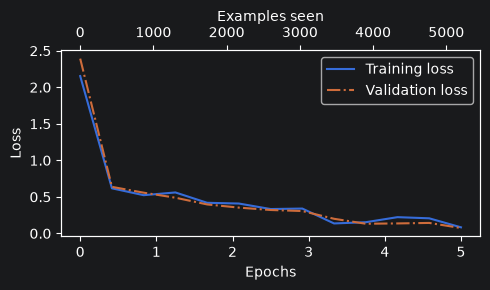

In [37]:
import matplotlib.pyplot as plt


def plot_values(
    epochs_seen: torch.Tensor,
    examples_seen: torch.Tensor,
    train_values: list[float],
    val_values: list[float],
    label: str = "loss",
) -> None:
    """Plot aligned training and validation metrics against two x-axes.

    Args:
        epochs_seen: Approximate epoch positions shaped `(num_evaluations,)`.
        examples_seen: Approximate processed-example counts shaped
            `(num_evaluations,)`.
        train_values: Training metric recorded at each evaluation.
        val_values: Validation metric recorded at each evaluation.
        label: Metric name used for labels and the PDF filename.

    Returns:
        None.
    """
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Both metric histories share the lower epoch axis.
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen,
        val_values,
        linestyle="-.",
        label=f"Validation {label}",
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # An invisible series aligns a second x-axis with examples_seen.
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()
    fig.savefig(f"{label}-plot.pdf")
    plt.show()


# Both tensors: (num_evaluations,), aligned with the loss histories
# Positions are interpolated because exact counters were not stored per event.
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(
    0,
    examples_seen,
    len(train_losses),
)
plot_values(
    epochs_tensor,
    examples_seen_tensor,
    train_losses,
    val_losses,
)

### Plotting per-epoch accuracy

Accuracy histories contain one value per completed epoch rather than one per periodic loss evaluation. Construct axes with matching
length and reuse the plotting helper. Values remain fractions, so `1.0` represents 100% accuracy.

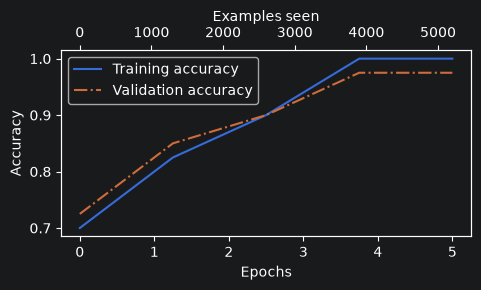

In [38]:
# Both tensors: (num_epochs,), aligned with one accuracy pair per epoch
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(
    0,
    examples_seen,
    len(train_accs),
)
# Accuracy values remain fractions in [0, 1] rather than percentages.
plot_values(
    epochs_tensor,
    examples_seen_tensor,
    train_accs,
    val_accs,
    label="accuracy",
)

## 6.24 Reporting final classification accuracy

Evaluate every available batch after model-selection decisions are complete. Validation and test loaders retain incomplete final batches,
so all held-out examples contribute. The training loader still drops its five-example remainder.

In [39]:
# Use every batch available from each loader for final reporting.
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation accuracy: {val_accuracy * 100:.2f}%")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


## 6.25 Classifying new messages

Inference must reproduce training preprocessing: use the same tokenizer, cap inputs at model capacity, and pad to the training dataset's
`max_length`. The classifier reads final-position logits and maps label `1` to `spam` and label `0` to the user-facing phrase `not spam`.

Unlike training, inference disables dropout and gradient tracking. The helper restores the model's previous mode afterward so it can be
called safely during either a training or evaluation workflow.

In [ ]:
def classify_review(
    text: str,
    model: GPTModel,
    tokenizer: tiktoken.Encoding,
    device: torch.device,
    max_length: int | None = None,
    pad_token_id: int = 50256,
) -> str:
    """Classify one text string as spam or not spam.

    Args:
        text: Message to classify.
        model: Fine-tuned GPT classifier with a two-class output head.
        tokenizer: GPT-2 tokenizer used during dataset preparation.
        device: CPU or CUDA device shared by model and input tensor.
        max_length: Padded input length, or `None` for model capacity. Values
            above model capacity are capped automatically.
        pad_token_id: Token ID appended to match the selected input length.

    Returns:
        `"spam"` for predicted label `1`; otherwise `"not spam"` for label `0`.

    Raises:
        ValueError: If the effective input length is not positive.
    """
    # Tokenization produces a variable-length Python list of token IDs.
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    effective_max_length = (
        supported_context_length
        if max_length is None
        else min(max_length, supported_context_length)
    )
    if effective_max_length <= 0:
        raise ValueError("max_length must select at least one token position")

    # Truncate first, then right-pad to the same length used during training.
    input_ids = input_ids[:effective_max_length]
    input_ids += [pad_token_id] * (effective_max_length - len(input_ids))

    # input_tensor: (batch_size=1, num_tokens=effective_max_length)
    input_tensor = torch.tensor(
        input_ids,
        dtype=torch.long,
        device=device,
    ).unsqueeze(0)

    # Preserve the caller's mode while disabling dropout for inference.
    was_training = model.training
    model.eval()
    try:
        with torch.no_grad():
            # last_token_logits: (batch_size=1, num_classes=2)
            last_token_logits = model(input_tensor)[:, -1, :]
        predicted_label = torch.argmax(last_token_logits, dim=-1).item()
    finally:
        # Restore mode even if inference raises an exception.
        model.train(was_training)

    return "spam" if predicted_label == 1 else "not spam"

### Checking contrasting examples

Run one obvious spam message and one ordinary personal message through the same inference function. These examples demonstrate the API but
do not replace aggregate test-set evaluation or analysis of ambiguous and adversarial messages.

In [41]:
# A prize-and-cash message should map to label 1 (spam).
spam_example = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
print(
    classify_review(
        spam_example,
        model,
        tokenizer,
        device,
        max_length=train_dataset.max_length,
    )
)

spam


In [42]:
# An ordinary dinner-plan message should map to label 0 (not spam).
ham_example = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)
print(
    classify_review(
        ham_example,
        model,
        tokenizer,
        device,
        max_length=train_dataset.max_length,
    )
)

not spam


## 6.26 Saving the fine-tuned classifier

Persist the model's `state_dict` after training. This captures the pretrained tensors plus all classification updates, including the new
two-class output head. The ignored `.pth` artifact can be reused locally without committing hundreds of megabytes to Git.

In [43]:
# Save learned parameters and registered buffers, not Python model code.
torch.save(model.state_dict(), "review_classifier.pth")

### Restoring classifier state

Load tensors onto the selected device and apply them to an already constructed matching architecture. `weights_only=True` restricts
loading to tensor-oriented state rather than arbitrary pickled objects. Optimizer state is unnecessary for inference-only restoration.

In [ ]:
# Reuse the existing matching architecture and place tensors on its device.
model_state_dict = torch.load(
    "review_classifier.pth",
    map_location=device,
    weights_only=True,
)
model.load_state_dict(model_state_dict)

## Chapter 6 summary

The chapter now completes the classification workflow:

- prepare balanced, fixed-length SMS batches;
- adapt pretrained GPT-2 representations through partial fine-tuning;
- measure loss and held-out accuracy;
- classify new messages with training-consistent preprocessing; and
- save and restore model state for later inference.

A saved `state_dict` contains learned tensors rather than architecture code. Correct restoration therefore requires the same GPT
configuration and two-class output head used during fine-tuning.